# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

C:\Users\satya\AppData\Roaming\Python\Python313\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

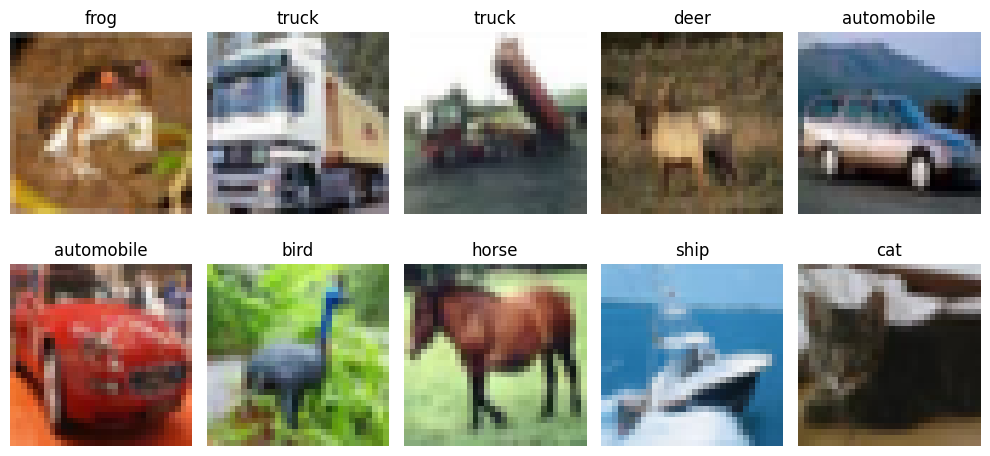

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [7]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2789 - loss: 1.9793 - val_accuracy: 0.3236 - val_loss: 1.8535
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3168 - loss: 1.8629 - val_accuracy: 0.3684 - val_loss: 1.7735
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3424 - loss: 1.7994 - val_accuracy: 0.3782 - val_loss: 1.7470
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3537 - loss: 1.7696 - val_accuracy: 0.4014 - val_loss: 1.6956
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3625 - loss: 1.7456 - val_accuracy: 0.3902 - val_loss: 1.7008
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3784 - loss: 1.7164 - val_accuracy: 0.4118 - val_loss: 1.6737
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3784 - loss: 1.7077 - val_accuracy: 0.4044 - val_loss: 1.6658
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3859 - loss: 1.6880 - val_accuracy: 0.

In [8]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4328 - loss: 1.6077
ANN Test Accuracy: 0.4327999949455261


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [8]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

C:\Users\satya\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.4609 - loss: 1.5164 - val_accuracy: 0.5290 - val_loss: 1.3144
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.6018 - loss: 1.1303 - val_accuracy: 0.6346 - val_loss: 1.0367
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.6688 - loss: 0.9602 - val_accuracy: 0.6496 - val_loss: 1.0078
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7077 - loss: 0.8438 - val_accuracy: 0.7098 - val_loss: 0.8591
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.7387 - loss: 0.7450 - val_accuracy: 0.7084 - val_loss: 0.8374
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.7653 - loss: 0.6727 - val_accuracy: 0.7082 - val_loss: 0.8687
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 53ms/step - accuracy: 0.7860 - loss: 0.6046 - val_accuracy: 0.7144 - val_loss: 0.8989
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.8119 - loss: 0.5339 - 

In [9]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7233 - loss: 0.9767
CNN Test Accuracy: 0.7232999801635742


## 📈 Compare Learning Curves

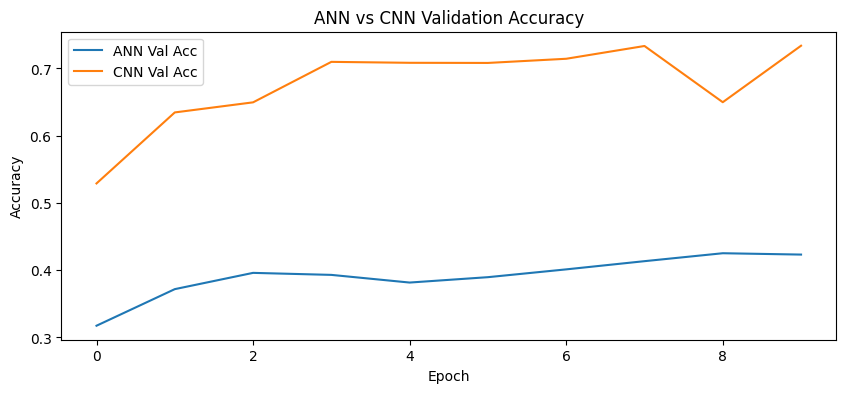

In [10]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 📊 Final Comparison Table

In [13]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4315
1,CNN,0.7233


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

### 1- Increase ANN layers and observe performance

In [15]:
ann_model_inc_layers = models.Sequential([
  layers.Dense(512, activation='relu', input_shape=(3072,)),
  layers.Dropout(0.3),

  layers.Dense(256, activation='relu'),
  layers.Dropout(0.3),

  layers.Dense(128, activation='relu'),
  layers.Dense(64, activation='relu'),

  layers.Dense(10, activation='softmax')
])

ann_model_inc_layers.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

ann_history = ann_model_inc_layers.fit(
  x_train_flat, y_train,
  epochs=10,
  validation_split=0.1,
  batch_size=64
)


C:\Users\satya\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.2414 - loss: 2.0318 - val_accuracy: 0.3276 - val_loss: 1.8613
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.3005 - loss: 1.9002 - val_accuracy: 0.3216 - val_loss: 1.8512
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.3232 - loss: 1.8521 - val_accuracy: 0.3636 - val_loss: 1.8003
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3322 - loss: 1.8244 - val_accuracy: 0.3484 - val_loss: 1.8071
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3453 - loss: 1.7914 - val_accuracy: 0.3858 - val_loss: 1.7359
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3519 - loss: 1.7793 - val_accuracy: 0.3824 - val_loss: 1.7530
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3624 - loss: 1.7567 - val_accuracy: 0.3996 - val_loss: 1.7201
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3652 - loss: 1.7468 - val_ac

In [16]:
ann_test_loss, ann_test_acc = ann_model_inc_layers.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy: (after increased layers)", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4065 - loss: 1.6850
ANN Test Accuracy: (after increased layers) 0.4065000116825104


### NOTE : Increasing number of layers in ANN does not significantly increase the accuracy
- Trying the ANN with Batch Normalization

In [17]:
ann_model_bn = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),

    layers.Dense(10, activation='softmax')
])

ann_model_bn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model_bn.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.3624 - loss: 1.8130 - val_accuracy: 0.3618 - val_loss: 1.8599
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4079 - loss: 1.6643 - val_accuracy: 0.3462 - val_loss: 1.7896
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4248 - loss: 1.6176 - val_accuracy: 0.1216 - val_loss: 4.0244
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4330 - loss: 1.5955 - val_accuracy: 0.4272 - val_loss: 1.6089
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4391 - loss: 1.5703 - val_accuracy: 0.4268 - val_loss: 1.6329
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4511 - loss: 1.5395 - val_accuracy: 0.4352 - val_loss: 1.6000
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4583 - loss: 1.5235 - val_accuracy: 0.4574 - val_loss: 1.6011
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4618 - loss: 1.5060 - val_accuracy:

In [18]:
ann_test_loss, ann_test_acc = ann_model_bn.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy: (after batch normalization)", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4676 - loss: 1.4925
ANN Test Accuracy: (after batch normalization) 0.4675999879837036


### 2- Change CNN filters from 32→64→128 
- This is already done in the previous CNN model

### 3- Increase epochs to 20

a - ANN

In [19]:
ann_model_inc_epochs = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(10, activation='softmax')
])

ann_model_inc_epochs.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model_inc_epochs.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.3584 - loss: 1.8041 - val_accuracy: 0.3510 - val_loss: 1.8882
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4087 - loss: 1.6586 - val_accuracy: 0.3612 - val_loss: 1.7809
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4282 - loss: 1.6166 - val_accuracy: 0.3858 - val_loss: 2.0497
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.4362 - loss: 1.5857 - val_accuracy: 0.2858 - val_loss: 2.2171
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.4459 - loss: 1.5629 - val_accuracy: 0.3250 - val_loss: 2.0210
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4518 - loss: 1.5436 - val_accuracy: 0.4294 - val_loss: 1.5829
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4573 - loss: 1.5278 - val_accuracy: 0.4718 - val_loss: 1.5174
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4580 - loss: 1.5168 - val_accura

In [21]:
ann_test_loss, ann_test_acc = ann_model_inc_epochs.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy: (after increased epochs)", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4877 - loss: 1.4368
ANN Test Accuracy: (after increased epochs) 0.4876999855041504


b - CNN 

In [22]:
cnn_model_inc_epochs = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_inc_epochs.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model_inc_epochs.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

C:\Users\satya\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.4667 - loss: 1.4822 - val_accuracy: 0.5146 - val_loss: 1.3531
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.6115 - loss: 1.1056 - val_accuracy: 0.6446 - val_loss: 1.0199
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.6729 - loss: 0.9385 - val_accuracy: 0.6676 - val_loss: 0.9436
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.7122 - loss: 0.8240 - val_accuracy: 0.7002 - val_loss: 0.8672
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.7474 - loss: 0.7259 - val_accuracy: 0.7252 - val_loss: 0.8335
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.7708 - loss: 0.6526 - val_accuracy: 0.7020 - val_loss: 0.9050
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.7951 - loss: 0.5824 - val_accuracy: 0.7184 - val_loss: 0.8545
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.8162 - loss: 0.5203 - 

In [24]:
cnn_test_loss, cnn_test_acc = cnn_model_inc_epochs.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:(after increased epochs)", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7219 - loss: 1.3245
CNN Test Accuracy:(after increased epochs) 0.7218999862670898


### Comparison of the learning curves of the two models after optimizations

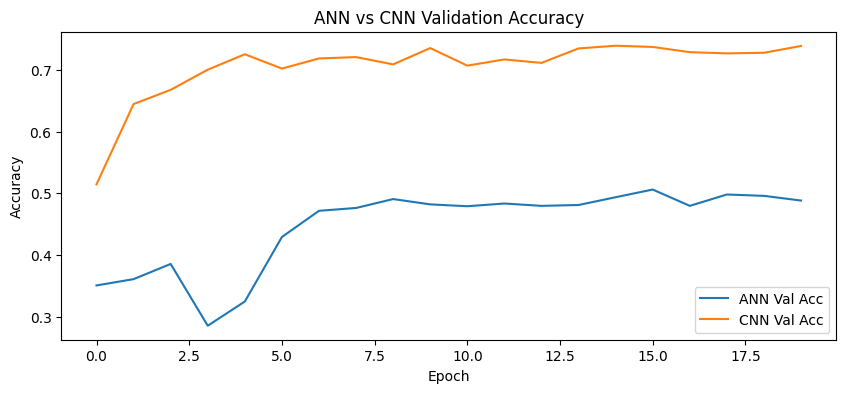

In [25]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

In [26]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4877
1,CNN,0.7219


### Note: ANN improved with increased epochs but CNN did not have much effect of the change

### 4 - Add **EarlyStopping**
### 5 - Add **data augmentation training**

# 🚀 Training Strategy Upgrade: Data Augmentation and Early Stopping
This strategy improves generalization by generating transformed images.

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

# Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# CNN with Data Augmentation
aug_cnn_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, 3, padding='same', activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Train the model
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

# Evaluate on test set
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test,
    verbose=1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.4333 - loss: 1.6425 - val_accuracy: 0.4896 - val_loss: 1.4637
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.5449 - loss: 1.2893 - val_accuracy: 0.5848 - val_loss: 1.1475
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.5784 - loss: 1.1967 - val_accuracy: 0.5946 - val_loss: 1.2406
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.6013 - loss: 1.1323 - val_accuracy: 0.6238 - val_loss: 1.0981
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 27ms/step - accuracy: 0.6165 - loss: 1.0925 - val_accuracy: 0.6284 - val_loss: 1.1381
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.6278 - loss: 1.0635 - val_accuracy: 0.6542 - val_loss: 1.0083
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.6383 - loss: 1.0344 - val_accuracy: 0.5922 - val_loss: 1.1647
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.6470 - loss: 1.0093 - 

In [32]:
print("CNN Test Accuracy:(after increased epochs)", aug_test_acc)

CNN Test Accuracy:(after increased epochs) 0.6471999883651733


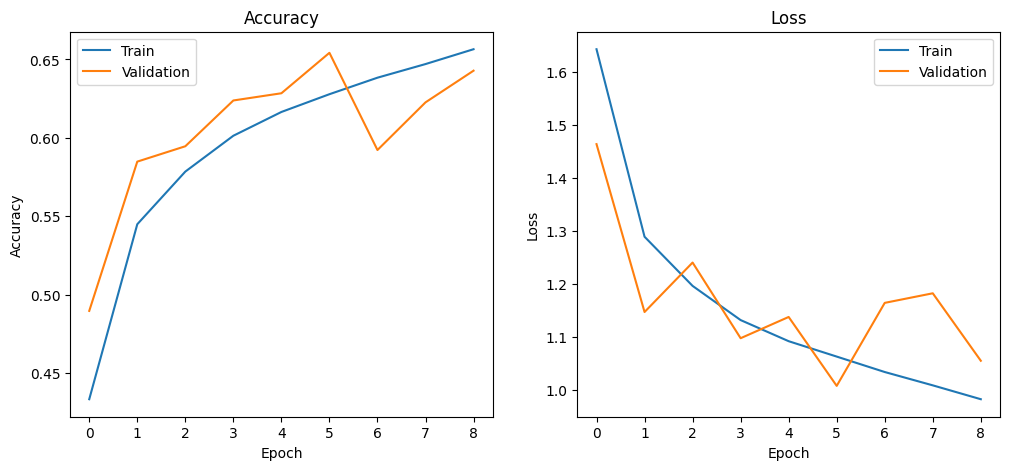

In [33]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(aug_history.history['accuracy'], label='Train')
plt.plot(aug_history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(aug_history.history['loss'], label='Train')
plt.plot(aug_history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**